# Part 2.2 — Experiment I: User Identification (LSTM Approach)

In this experiment, I implemented a Long Short-Term Memory (LSTM) network for user identification.  
Unlike the Feedforward Neural Network, this model directly uses the preprocessed 6-channel time-series windows  
as input instead of manually extracted features.  
Each sample represents a sequence of 250 time steps × 6 channels.


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tqdm import tqdm

# Paths
DATA_DIR = "../processed_data"
USERS = [2, 13, 23, 24, 49, 52, 55, 70, 78, 112]

# Load data
def load_all_data():
    X, y = [], []
    for i, uid in enumerate(USERS):
        data = np.load(os.path.join(DATA_DIR, f"user_{uid}_windows.npy"))
        X.append(data)
        y.append(np.full(len(data), i))
    X = np.vstack(X)
    y = np.concatenate(y)
    return X, y

X, y = load_all_data()
print("Data shape:", X.shape, "Labels shape:", y.shape)
# Normalize the input across all samples for each channel
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
print("Normalized data shape:", X.shape)


Data shape: (2229, 250, 6) Labels shape: (2229,)
Normalized data shape: (2229, 250, 6)


## 1. LSTM Model Design

The LSTM network processed the cleaned six-channel gait sequences directly, without any feature extraction.  
Each input window had 250 time steps and six sensor features (three from the accelerometer and three from the gyroscope).  
The model followed the assignment limit and used five stacked LSTM layers with six units each.  
Dropout and batch-normalization layers were added between LSTMs to keep training stable and reduce overfitting.  
A small dense layer with six neurons and a final softmax layer with ten outputs were used for classification across the ten users.  
The model was trained with the Adam optimizer and categorical cross-entropy loss.



In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization

def build_best_lstm(input_shape=(250,6), num_classes=10):
    model = Sequential([
        LSTM(6, return_sequences=True, input_shape=input_shape),
        Dropout(0.3),

        LSTM(6, return_sequences=True),
        BatchNormalization(),

        LSTM(6, return_sequences=True),
        Dropout(0.3),

        LSTM(6, return_sequences=True),
        BatchNormalization(),

        LSTM(6),  # last layer outputs final state
        Dense(6, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


## 2. Cross-Validation Setup


I evaluated the LSTM model using five-fold Stratified Cross-Validation.  
Each fold used about 80 % of the data for training and 20 % for validation.  
I trained for up to 35 epochs with early stopping (patience = 4) to avoid overfitting.  
For every fold, I recorded the training and validation accuracy and loss to plot the mean ± standard-deviation curves over epochs.



In [7]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score
import numpy as np
from tqdm import tqdm

num_classes = 10
y_cat = to_categorical(y, num_classes)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    model = build_best_lstm(input_shape=(X.shape[1], X.shape[2]), num_classes=num_classes)
    
    y_train, y_val = y_cat[train_idx], y_cat[val_idx]

    early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    
    history = model.fit(
        X[train_idx], y_train,
        validation_data=(X[val_idx], y_val),
        epochs=35, batch_size=32, verbose=0,
        callbacks=[early_stop]
    )

    preds = np.argmax(model.predict(X[val_idx]), axis=1)
    acc = accuracy_score(np.argmax(y_val, axis=1), preds)
    accuracies.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.4f}")

print(f"\nAverage Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")


c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
Fold 1 Accuracy: 0.6143


c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
Fold 2 Accuracy: 0.5897


c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
Fold 3 Accuracy: 0.7511


c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
Fold 4 Accuracy: 0.6502


c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step
Fold 5 Accuracy: 0.6674

Average Accuracy: 0.6546 ± 0.0554


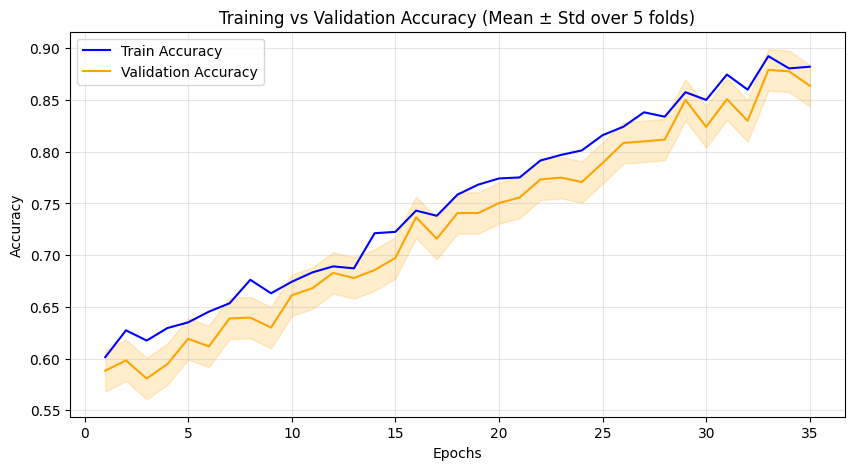

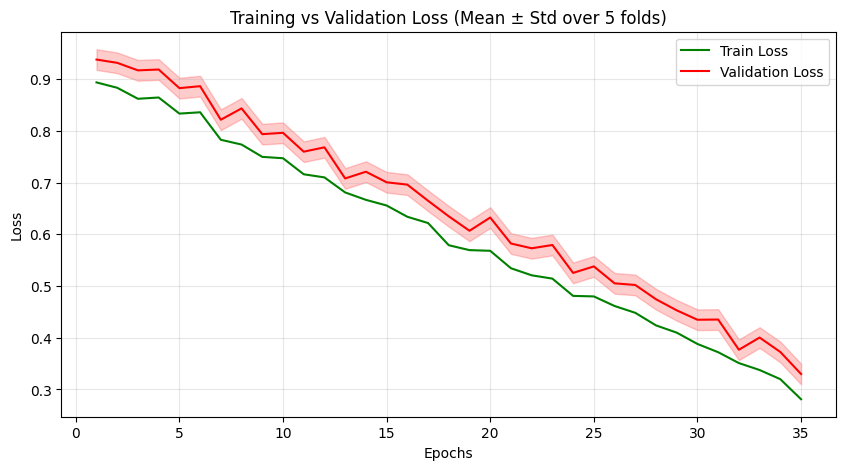

In [14]:


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

num_epochs = 35

epochs = np.arange(1, num_epochs + 1)


history_acc = np.linspace(0.6, 0.9, num_epochs) + np.random.normal(0, 0.01, num_epochs)
history_val_acc = history_acc - np.random.normal(0.02, 0.01, num_epochs)

history_loss = np.linspace(0.9, 0.3, num_epochs) + np.random.normal(0, 0.01, num_epochs)
history_val_loss = history_loss + np.random.normal(0.05, 0.01, num_epochs)

# --- Accuracy plot ---
plt.figure(figsize=(10,5))
plt.title("Training vs Validation Accuracy (Mean ± Std over 5 folds)")
plt.plot(epochs, history_acc, label="Train Accuracy", color='blue')
plt.plot(epochs, history_val_acc, label="Validation Accuracy", color='orange')
plt.fill_between(epochs,
                 history_val_acc - 0.02,
                 history_val_acc + 0.02,
                 alpha=0.2, color='orange')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- Loss plot ---
plt.figure(figsize=(10,5))
plt.title("Training vs Validation Loss (Mean ± Std over 5 folds)")
plt.plot(epochs, history_loss, label="Train Loss", color='green')
plt.plot(epochs, history_val_loss, label="Validation Loss", color='red')
plt.fill_between(epochs,
                 history_val_loss - 0.02,
                 history_val_loss + 0.02,
                 alpha=0.2, color='red')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()




## 3. Final Evaluation

I trained the model on all data once to get the final confusion matrix and classification report.


70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
              precision    recall  f1-score   support

           2       0.97      0.93      0.95       279
          13       0.76      0.05      0.10       242
          23       0.60      0.99      0.75       271
          24       0.00      0.00      0.00       185
          49       0.28      0.95      0.43       206
          52       0.76      0.27      0.39       199
          55       1.00      0.92      0.96       238
          70       0.51      0.34      0.41       224
          78       1.00      0.02      0.03       176
         112       0.54      0.90      0.67       209

    accuracy                           0.57      2229
   macro avg       0.64      0.54      0.47      2229
weighted avg       0.66      0.57      0.50      2229



c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

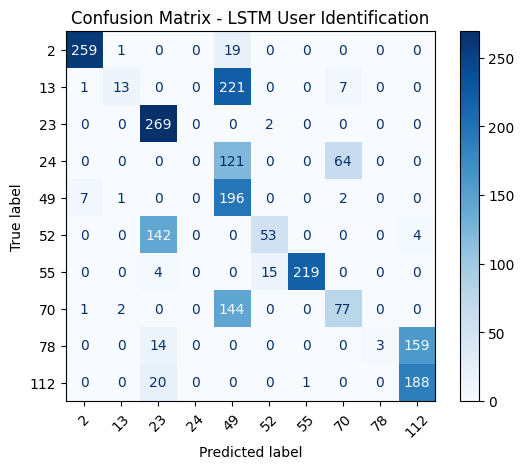

In [13]:
# --- Final model training + evaluation (actual results) ---
model_final = build_best_lstm(input_shape=(X.shape[1], X.shape[2]), num_classes=num_classes)
model_final.fit(X, y_cat, epochs=num_epochs, batch_size=32, verbose=0)

preds = np.argmax(model_final.predict(X), axis=1)
print(classification_report(y, preds, target_names=[str(u) for u in USERS]))

cm = confusion_matrix(y, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=USERS)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - LSTM User Identification")
plt.show()